It means to **change the numerical values into categorical values**.Normally it is not needed but can be preffered in some cases (especially when range is very high).

Two methods are available
- 1. Discritization (binning)
- 2. Binarization



---



---



---



# Discritization (binning)

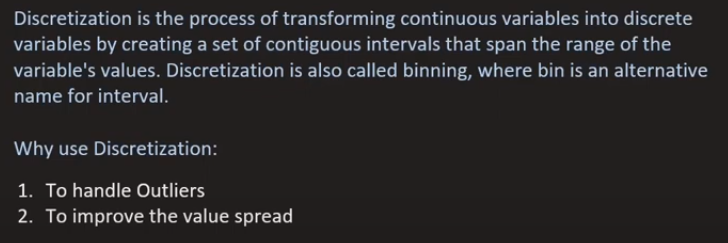

# Types

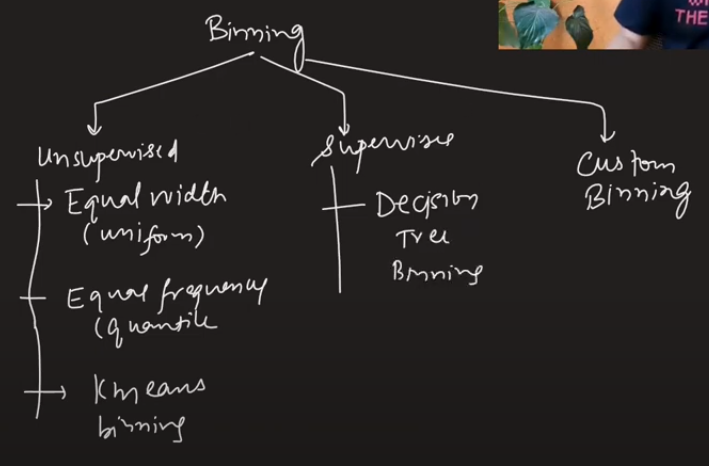



---



---



# **1. Unspervised binning**

# A. EQUAL WIDTH/UNIFORM BINNING
- Outliers handles effectively
- No change in spread
- Bins numbers needs to be told
- Formulae is given below

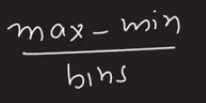

#B. EQUAL FREQUENCY/QUANTILE BINNING
- Used frequently
- Handles outliers
- Improve spread of data
- By default present in sklearn
- Example is given below

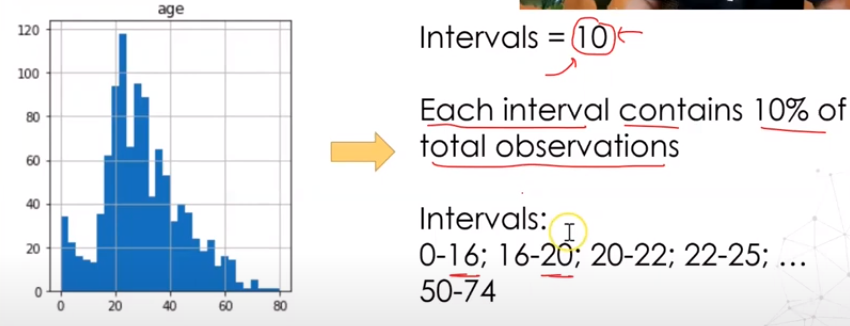

#C. KMEANS BINNING
- Used when data is in clusteers form
- Kmeans clustering is performed and eventually when we got the final centriods value these will be termed as our bins.

In Sklearn during implementing Binning we have to define 3 parameters
- bins#
- Strategy (method)
- Encoding technique ( ordinal / OHE )

# **2. Custom binnig**

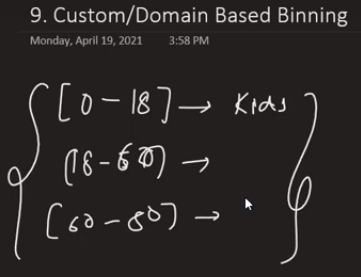

# **3. Supervised binning**
- Decision tree binning ( not discussed )



---

---





# Code for Binning (Only Unsupervised)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.preprocessing import KBinsDiscretizer
from sklearn.compose import ColumnTransformer

In [2]:
df = pd.read_csv('train.csv',usecols=['Age','Fare','Survived'])

In [6]:
df.dropna(inplace=True)
print(df.shape)
df.head()

(714, 3)


,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [7]:
X = df.iloc[:,1:]
y = df.iloc[:,0]
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

# Without binning

In [8]:
clf = DecisionTreeClassifier()
clf.fit(X_train,y_train)
y_pred = clf.predict(X_test)
print(accuracy_score(y_test,y_pred))
print(np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv=10,scoring='accuracy')))

0.6293706293706294
0.6373239436619718


# With binning

In [9]:
kbin_age = KBinsDiscretizer(n_bins=15,encode='ordinal',strategy='quantile')
kbin_fare = KBinsDiscretizer(n_bins=15,encode='ordinal',strategy='quantile')

In [10]:
trf = ColumnTransformer([
    ('first',kbin_age,[0]),
    ('second',kbin_fare,[1])
])

In [11]:
X_train_trf = trf.fit_transform(X_train)
X_test_trf = trf.transform(X_test)

In [12]:
trf.named_transformers_['first']

KBinsDiscretizer(encode='ordinal', n_bins=15)

In [13]:
trf.named_transformers_['first'].bin_edges_

array([array([ 0.42,  6.  , 16.  , 19.  , 21.  , 23.  , 25.  , 28.  , 30.  ,
              32.  , 35.  , 38.  , 42.  , 47.  , 54.  , 80.  ])             ],
      dtype=object)

In [14]:
# To show dataframe of events
output = pd.DataFrame({
    'age':X_train['Age'],
    'age_trf':X_train_trf[:,0],
    'fare':X_train['Fare'],
    'fare_trf':X_train_trf[:,1]
})
output['age_labels'] = pd.cut(x=X_train['Age'],
                                    bins=trf.named_transformers_['first'].bin_edges_[0].tolist())
output['fare_labels'] = pd.cut(x=X_train['Fare'],
                                    bins=trf.named_transformers_['second'].bin_edges_[0].tolist())
output.sample(5)

,age,age_trf,fare,fare_trf,age_labels,fare_labels
179,36.0,10.0,0.0000,0.0,"(35.0, 38.0]",NaN
604,35.0,10.0,26.5500,10.0,"(32.0, 35.0]","(26.0, 26.55]"
160,44.0,12.0,16.1000,7.0,"(42.0, 47.0]","(14.454, 18.75]"
479,2.0,0.0,12.2875,5.0,"(0.42, 6.0]","(10.5, 13.0]"
712,48.0,13.0,52.0000,12.0,"(47.0, 54.0]","(51.479, 76.292]"


In [15]:
clf = DecisionTreeClassifier()
clf.fit(X_train_trf,y_train)
y_pred2 = clf.predict(X_test_trf)
accuracy_score(y_test,y_pred2)

0.6363636363636364

In [16]:
X_trf = trf.fit_transform(X)
np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv=10,scoring='accuracy'))

0.6316705790297339



---



In [17]:
def discretize(bins,strategy):
    kbin_age = KBinsDiscretizer(n_bins=bins,encode='ordinal',strategy=strategy)
    kbin_fare = KBinsDiscretizer(n_bins=bins,encode='ordinal',strategy=strategy)

    trf = ColumnTransformer([
        ('first',kbin_age,[0]),
        ('second',kbin_fare,[1])
    ])

    X_trf = trf.fit_transform(X)
    print(np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv=10,scoring='accuracy')))

    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist(X['Age'])
    plt.title("Before")

    plt.subplot(122)
    plt.hist(X_trf[:,0],color='red')
    plt.title("After")

    plt.show()

    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist(X['Fare'])
    plt.title("Before")

    plt.subplot(122)
    plt.hist(X_trf[:,1],color='red')
    plt.title("Fare")

    plt.show()

0.630281690140845


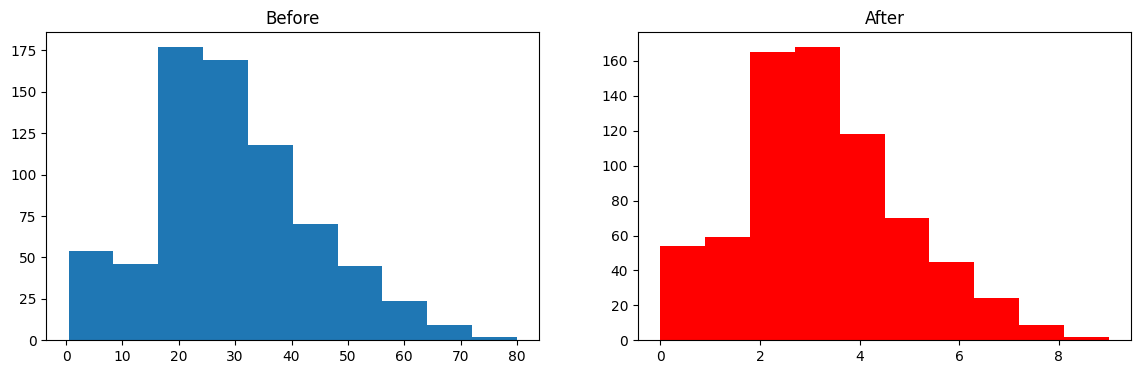

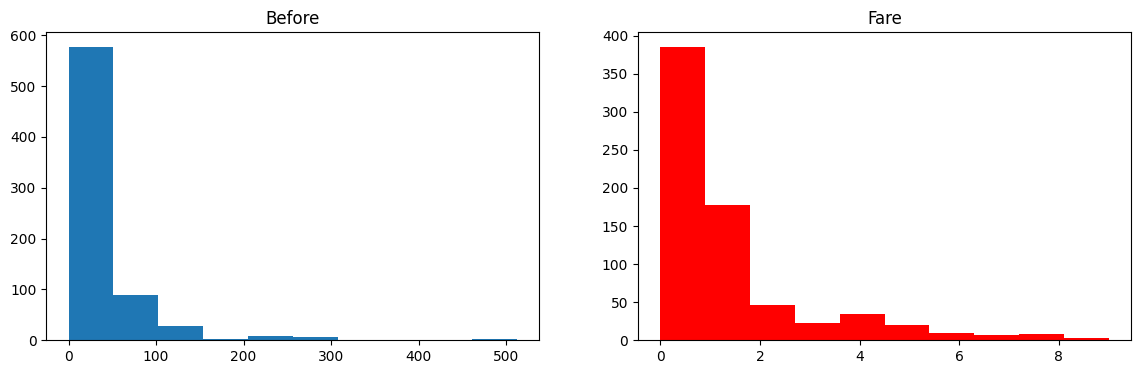

In [23]:
discretize(10,'kmeans')

0.6303012519561815


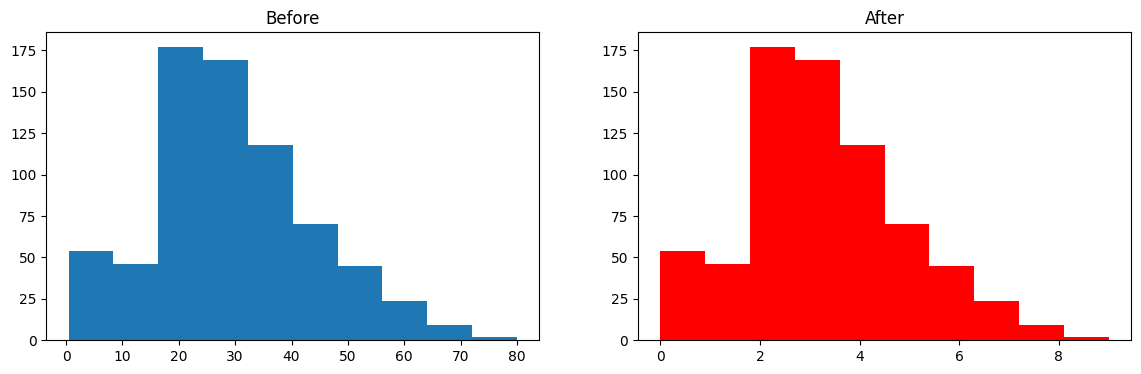

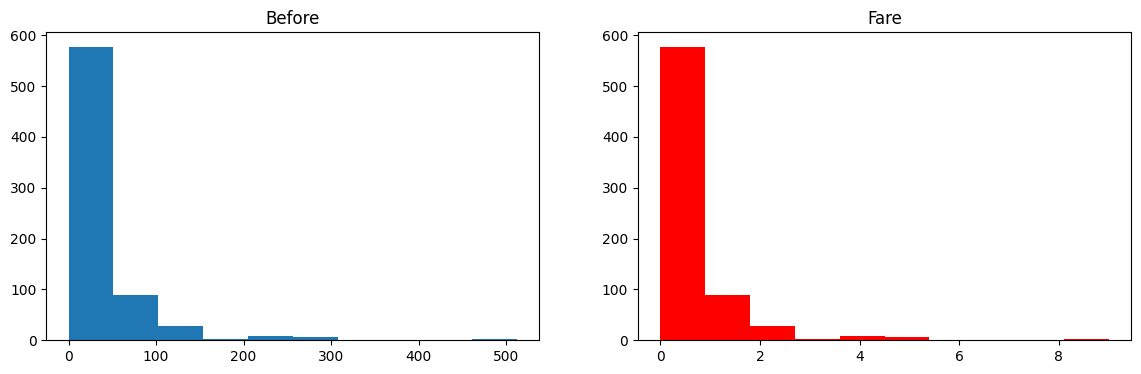

In [21]:
discretize(10,'uniform')

0.6303012519561814


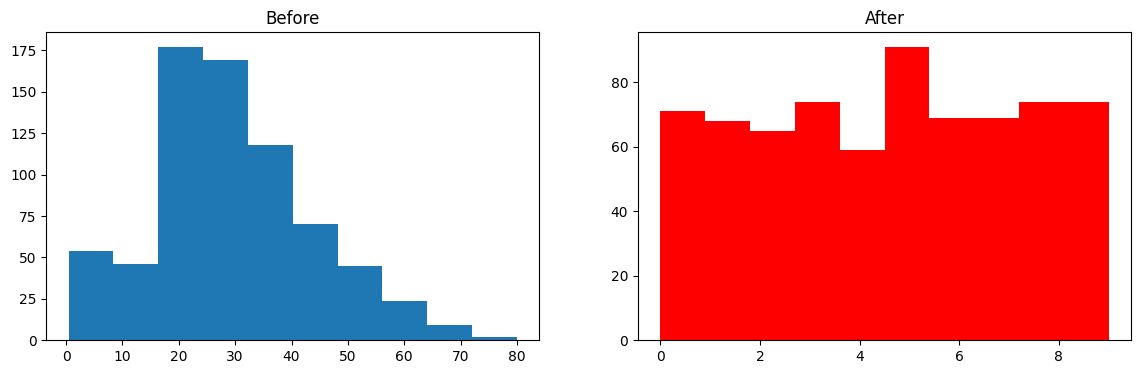

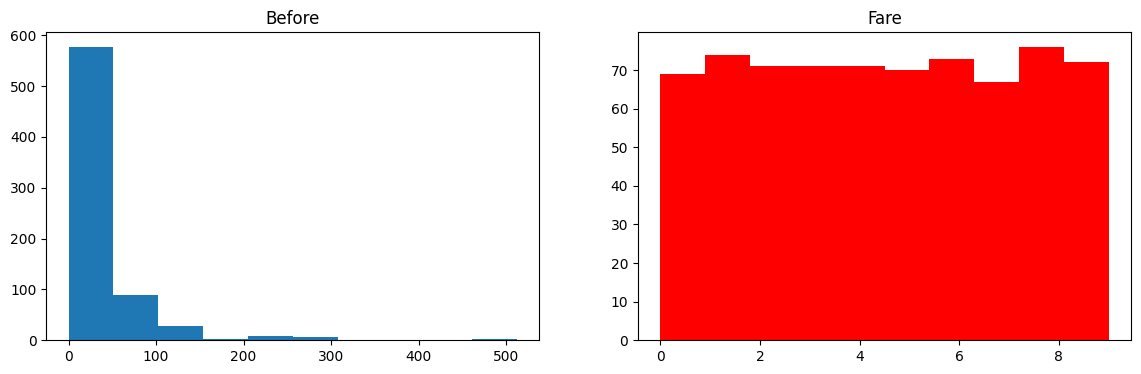

In [22]:
discretize(10,'quantile')



---



---



---



---



---



#BINARIZATION

Here we convert the **numerical data into binary data**. It is used in special scenarios

**EXAMPLES**
- i.e if annual salary needs to be changed into tax category or not then we can apply this i.e 10 lac >= 1 otherwise = 0 .  
- It can also be used in **IMAGE PROCESSING**.i.e we have colorful image having pixels value range from 1 to 255 then we can create condition in a way that if pixels value range from 0 to 127.5 then it will be 1(white) otherwise 0 (black)

**parameters in sklearn**
- Threshold (i.e 127.5)
- Copy (i.e True)...salary case

In [24]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score

from sklearn.compose import ColumnTransformer

In [25]:
df = pd.read_csv('train.csv')[['Age','Fare','SibSp','Parch','Survived']]

In [26]:
df.dropna(inplace=True)
df.head()

,Age,Fare,SibSp,Parch,Survived
0,22.0,7.2500,1,0,0
1,38.0,71.2833,1,0,1
2,26.0,7.9250,0,0,1
3,35.0,53.1000,1,0,1
4,35.0,8.0500,0,0,0


In [27]:
df['family'] = df['SibSp'] + df['Parch']
df.head()

,Age,Fare,SibSp,Parch,Survived,family
0,22.0,7.2500,1,0,0,1
1,38.0,71.2833,1,0,1,1
2,26.0,7.9250,0,0,1,0
3,35.0,53.1000,1,0,1,1
4,35.0,8.0500,0,0,0,0


In [28]:
df.drop(columns=['SibSp','Parch'],inplace=True)
df.head()

,Age,Fare,Survived,family
0,22.0,7.2500,0,1
1,38.0,71.2833,1,1
2,26.0,7.9250,1,0
3,35.0,53.1000,1,1
4,35.0,8.0500,0,0


In [29]:
X = df.drop(columns=['Survived'])
y = df['Survived']
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
X_train.head()

,Age,Fare,family
328,31.0,20.5250,2
73,26.0,14.4542,1
253,30.0,16.1000,1
719,33.0,7.7750,0
666,25.0,13.0000,0


# Without binarization

In [33]:
clf = DecisionTreeClassifier()
clf.fit(X_train,y_train)
y_pred = clf.predict(X_test)
accuracy_score(y_test,y_pred)

0.6223776223776224

In [34]:
np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv=10,scoring='accuracy'))

0.6457355242566509

# Applying Binarization


In [35]:
from sklearn.preprocessing import Binarizer

trf = ColumnTransformer([
    ('bin',Binarizer(copy=False),['family'])
],remainder='passthrough')

X_train_trf = trf.fit_transform(X_train)
X_test_trf = trf.transform(X_test)

pd.DataFrame(X_train_trf,columns=['family','Age','Fare'])

,family,Age,Fare
0,1.0,31.0,20.5250
1,1.0,26.0,14.4542
2,1.0,30.0,16.1000
3,0.0,33.0,7.7750
4,0.0,25.0,13.0000
...,...,...,...
566,1.0,46.0,61.1750
567,0.0,25.0,13.0000
568,0.0,41.0,134.5000
569,1.0,33.0,20.5250


In [36]:
clf = DecisionTreeClassifier()
clf.fit(X_train_trf,y_train)
y_pred2 = clf.predict(X_test_trf)

accuracy_score(y_test,y_pred2)

0.6153846153846154

In [37]:
X_trf = trf.fit_transform(X)
np.mean(cross_val_score(DecisionTreeClassifier(),X_trf,y,cv=10,scoring='accuracy'))

0.6275430359937403